**Exploring Saudi Daily Stocks Time Series Data**


**Time Series Analysis:**
Time series analysis is a statistical technique used to analyze and extract meaningful information from sequences of data points collected and ordered in time. These data points could represent observations of a variable at regular intervals, such as daily, weekly, monthly, etc. Time series analysis helps in understanding the underlying patterns, trends, and behavior of the data over time, making it invaluable in forecasting future values.

**ARIMA Models:**
ARIMA (AutoRegressive Integrated Moving Average) is a popular and powerful time series forecasting method. It's a combination of three components:
- **AutoRegressive (AR) component**: This component captures the relationship between the current observation and a number of lagged observations (i.e., observations from previous time steps).
- **Integrated (I) component**: This component accounts for differencing, which is the process of removing the trend or making the series stationary.
- **Moving Average (MA) component**: This component represents the relationship between the current observation and a residual error from a moving average model applied to lagged observations.

**Dataset Description:**
Sourced from Kaggle and containing Saudi Daily Stocks History (Tadawul), provides a valuable resource for analyzing the historical performance of stocks traded on the Tadawul stock exchange. Specifically, it includes daily stock price data for companies listed in Saudi Arabia. Our dataset is (Kingdom 4280) ,bwteen years 2008-2020.
About the Kingdom Company:
One of the companies within Saudi Daily Stocks History (Tadawul) represents a prominent entity within the Saudi Arabian economy. As a leading player in the Kingdom's business landscape, this company's stock performance can offer insights into broader economic trends and investor sentiment within the region.

**Application of ARIMA:**
Utilizing ARIMA models on the dataset allows us to leverage historical stock price data to make informed predictions about future price movements. By identifying patterns, trends, and seasonality within the data, ARIMA models can provide valuable forecasts, aiding in investment decision-making and risk management strategies.


# Preprocessing

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15,6
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error,mean_squared_error # Import mean_absolute_error

In [60]:
df = pd.read_csv('/content/KINGDOM_4280.csv')

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

df = df.sort_index(ascending=True)
print(df.head())

             open   high    low  close  change  change_percent  volume_traded  \
date                                                                            
2007-07-29  22.95  24.75  20.40  20.85   20.85            0.00     45278640.0   
2007-07-30  20.85  20.85  19.55  20.00   -0.85           -4.08     11410574.0   
2007-07-31  20.00  20.40  19.55  19.55   -0.45           -2.25      4810114.0   
2007-08-01  20.00  20.85  19.55  20.85    1.30            6.65     14814786.0   
2007-08-04  20.40  20.40  20.00  20.40   -0.45           -2.16      4519719.0   

            value_traded_SAR  number_trades  
date                                         
2007-07-29      9.729698e+08          86751  
2007-07-30      2.309738e+08          18054  
2007-07-31      9.527842e+07           8774  
2007-08-01      3.011238e+08          14353  
2007-08-04      9.167340e+07           7342  


In [61]:
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Check for missing values in the entire DataFrame
total_missing = df.isnull().sum().sum()
print("Total missing values:", total_missing)


Missing values in each column:
 open                1
high                1
low                 1
close               0
change              0
change_percent      0
volume_traded       0
value_traded_SAR    0
number_trades       0
dtype: int64
Total missing values: 3


In [62]:
# Replace missing values with the mean of each column
df.fillna(df.mean(), inplace=True)


In [63]:
KingdomStock = df.dropna()
KingdomStock = df['close']

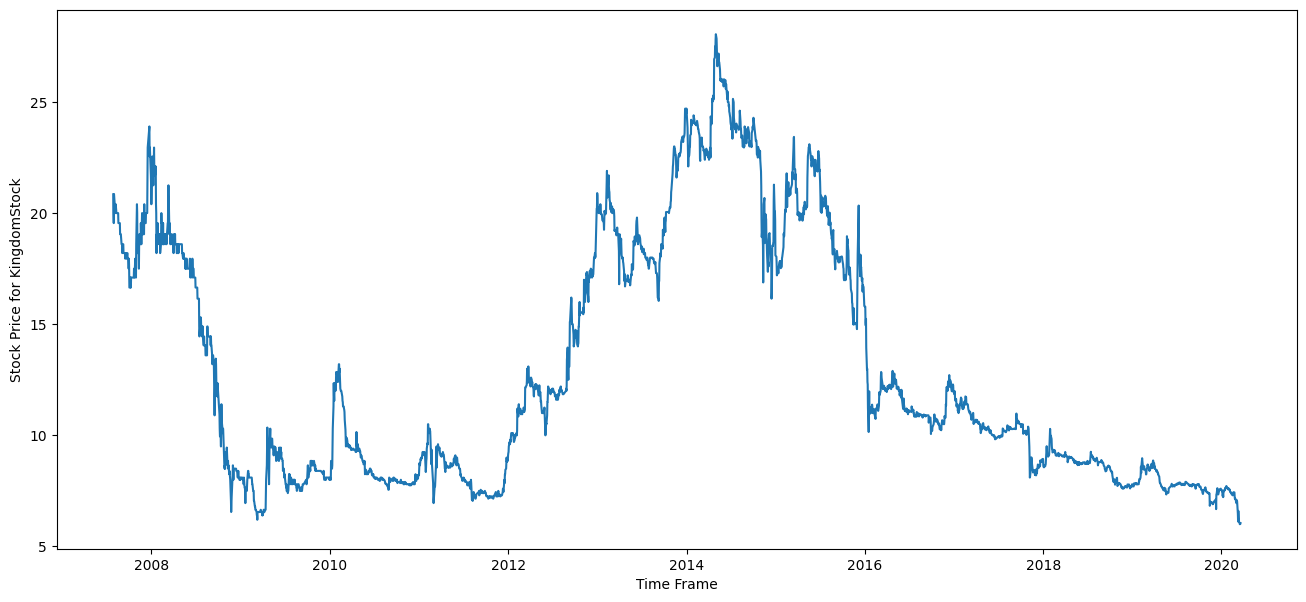

In [64]:
#Data Exploration
plt.figure(figsize=(16,7))
fig = plt.figure(1)
ax1 = fig.add_subplot(111)
ax1.set_xlabel('Time Frame')
ax1.set_ylabel('Stock Price for KingdomStock')
ax1.plot(KingdomStock)

#Step 1 Checking Stationarity

 checking stationarity is crucial before applying ARIMA. You can do this through visual inspection of a plot or by conducting statistical tests like the Augmented Dickey-Fuller (ADF) test.

 1.  Visual Inspection: Plot the time series
data to visually inspect for any trend or seasonality.
2. Augmented Dickey-Fuller (ADF) Test: Perform the ADF test to formally check for stationarity. This test provides a p-value, and if the p-value is less than a chosen significance level (e.g., 0.05), we reject the null hypothesis (the series is non-stationary) in favor of the alternative hypothesis (the series is stationary).

In [65]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# Define a function to check stationarity
def check_stationarity(timeseries):
    # Perform Dickey-Fuller test
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

check_stationarity(KingdomStock)


ADF Statistic: -1.5217542827506723
p-value: 0.5227236768506733
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567


Here P-value is 0.52 which is greater than 0.05, which means data is accepting the null hypothesis, which means data is **non-stationary**.

#Step 2 Making Series Stationary  


differencing is a common technique used to make a time series stationary. You can take the first difference to remove trends or seasonality components. If the time series is still not stationary after the first difference, you can continue differencing until it becomes stationary.

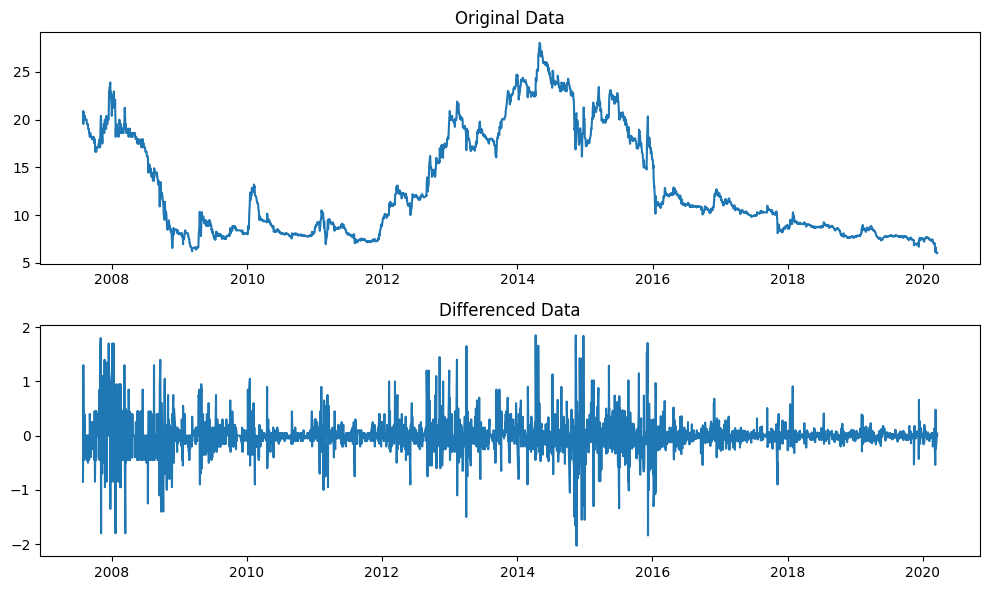

In [66]:

# Perform differencing
differenced_data = KingdomStock.diff().dropna()

# Plot original and differenced data for visualization
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(KingdomStock)
plt.title('Original Data')
plt.subplot(2, 1, 2)
plt.plot(differenced_data)
plt.title('Differenced Data')
plt.tight_layout()
plt.show()


In [67]:
# Again testing if data is stationary
check_stationarity(differenced_data)

ADF Statistic: -10.835462984010151
p-value: 1.6664822346224145e-19
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567


Here P-value is 1.66, which means we will be rejecting the null hypothesis. So data is **stationary.**

#Step 3 Filter out a validation


Here we are using the last 6 periods of our time series data as the validation sample. This means that we'll train our model on historical data, excluding the last 6 periods, and then test its performance on those 6 periods to see how accurately it predicts the future.

By using a validation sample, we can gain insights into how well our model performs in real-world scenarios and assess its accuracy before deploying it for making actual predictions.


In [68]:

X = KingdomStock.values
train_size = int(0.7 * len(X))
train, test = X[:train_size], X[train_size:]
print('Observations: %d' % (len(X)))
print('Training Observations: %d' % (len(train)))
print('Testing Observations: %d' % (len(test)))

Observations: 3155
Training Observations: 2208
Testing Observations: 947


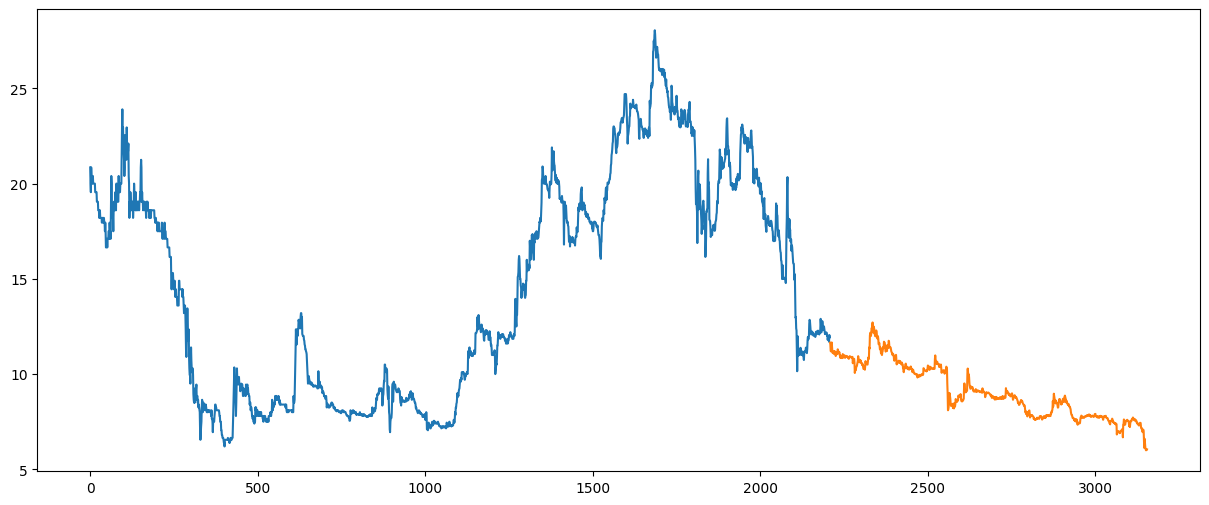

In [69]:
from matplotlib import pyplot
pyplot.plot(train)
pyplot.plot([None for i in train] + [x for x in test])
pyplot.show()


#Step 4 - Select AR and MA terms

Step 4 involves selecting the Autoregressive (AR) and Moving Average (MA) terms for the ARIMA model. This step helps determine the order of the ARIMA model, denoted as (p, d, q), where:

- p represents the number of lag observations included in the model (AR terms).
- d represents the degree of differencing (order of differencing).
- q represents the size of the moving average window (MA terms).

To select the AR and MA terms, we use two plots:

- **Autocorrelation Function (ACF) Plot**: This plot shows the correlation between the series and its lagged values. It helps determine the MA term (q) by identifying the lag beyond which most autocorrelations are not significant.

- **Partial Autocorrelation Function (PACF) Plot**: This plot shows the correlation between the series and its lagged values after removing the effects of intermediate lags. It helps determine the AR term (p) by identifying the lag beyond which most partial autocorrelations are not significant.

Here's a brief summary of interpretation:

For AR terms (p): Look for significant spikes in the PACF plot before they drop off.
For MA terms (q): Look for significant spikes in the ACF plot before they drop off.
Once you identify the orders of p and q, you can proceed with fitting the ARIMA model.

<Figure size 1600x700 with 0 Axes>

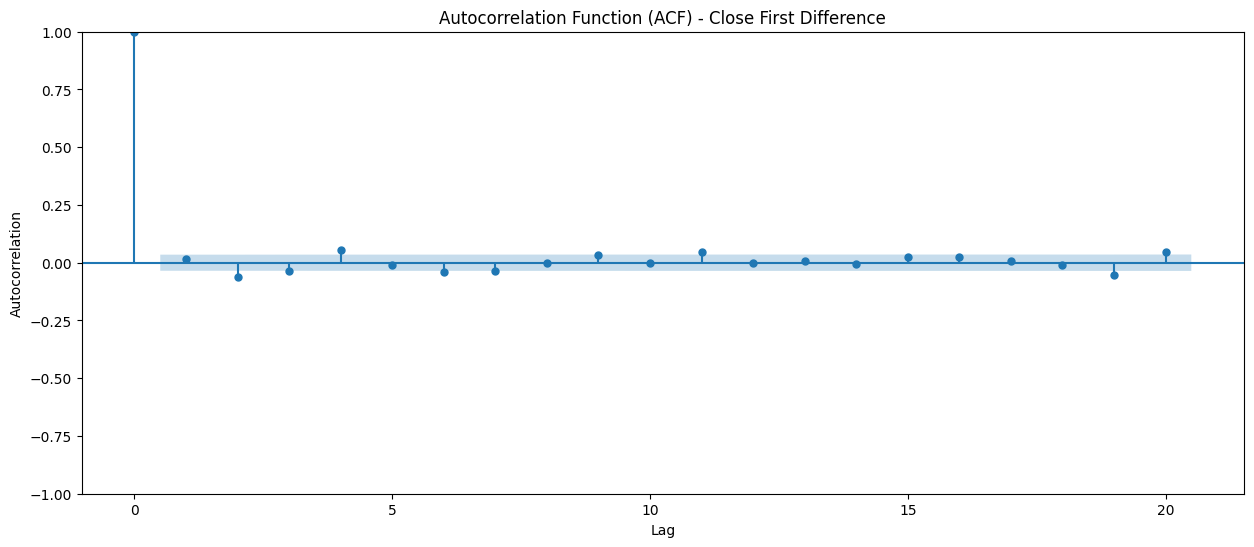

<Figure size 1600x700 with 0 Axes>

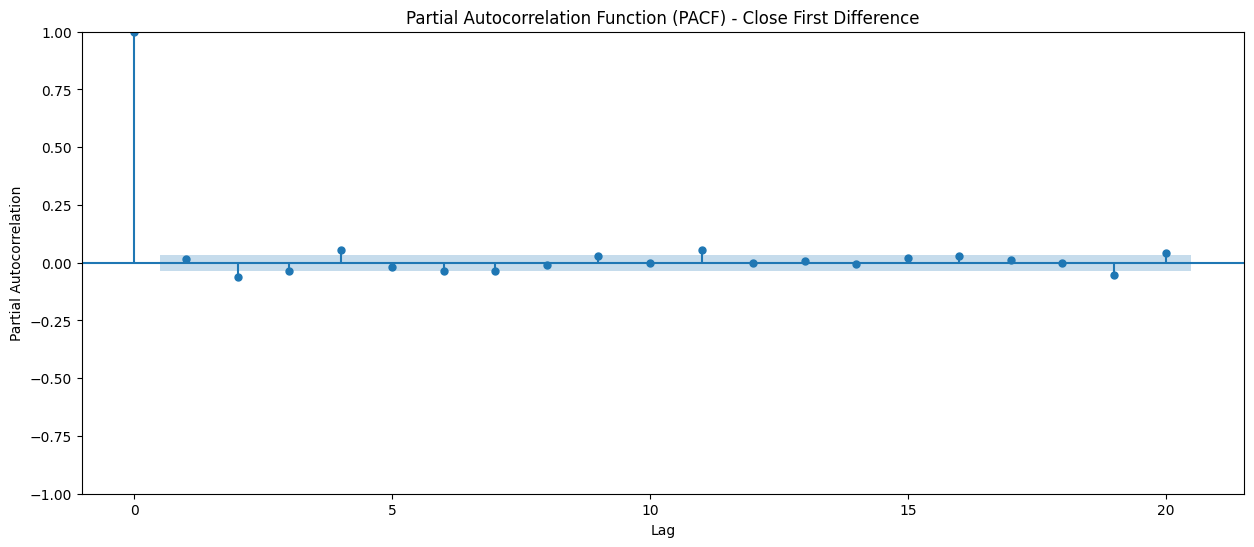

In [70]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Generate ACF plot for Close First Difference
plt.figure(figsize=(16,7))
plot_acf(differenced_data.dropna(), lags=20)
plt.title('Autocorrelation Function (ACF) - Close First Difference')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

# Generate PACF plot for Close First Difference
plt.figure(figsize=(16,7))

plot_pacf(differenced_data.dropna(), lags=20)
plt.title('Partial Autocorrelation Function (PACF) - Close First Difference')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.show()



#Step 5 Build The Model

In [71]:
# Build the ARIMA model
model = ARIMA(train, order=(1, 1, 1))
# Fit the model
model_fit = model.fit()
# Print the summary of the model fit
print(model_fit.summary())




                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2208
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -929.895
Date:                Sat, 11 May 2024   AIC                           1865.789
Time:                        22:06:56   BIC                           1882.887
Sample:                             0   HQIC                          1872.036
                               - 2208                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7525      0.207      3.639      0.000       0.347       1.158
ma.L1         -0.7704      0.201     -3.837      0.000      -1.164      -0.377
sigma2         0.1360      0.002     66.870      0.0

#Step 6 Validate The Model

In [72]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

# Forecast
forecast = model_fit.forecast(steps=len(test))
# Convert the forecasted values and test values to pandas Series
forecasted_series = pd.Series(forecast, name='ARIMA')
actual_series = pd.Series(test, name='Actual')
# Combine the forecasted and actual values into a DataFrame for comparison
comparison_df = pd.concat([forecasted_series, actual_series], axis=1)
# Print the comparison DataFrame
print(comparison_df)


         ARIMA  Actual
0    11.930240   11.65
1    11.930421   11.55
2    11.930557   11.21
3    11.930660   11.19
4    11.930737   11.55
..         ...     ...
942  11.930971    6.05
943  11.930971    6.00
944  11.930971    6.02
945  11.930971    6.01
946  11.930971    6.05

[947 rows x 2 columns]


In [73]:
mae = mean_absolute_error(test, forecast)  # Calculate MAE
print('Mean Absolute Error:', mae)


Mean Absolute Error: 2.8221351345172363


The MAE value you obtained, approximately 2.82, indicates the average absolute error between the actual values in the test set and the corresponding forecasted values.

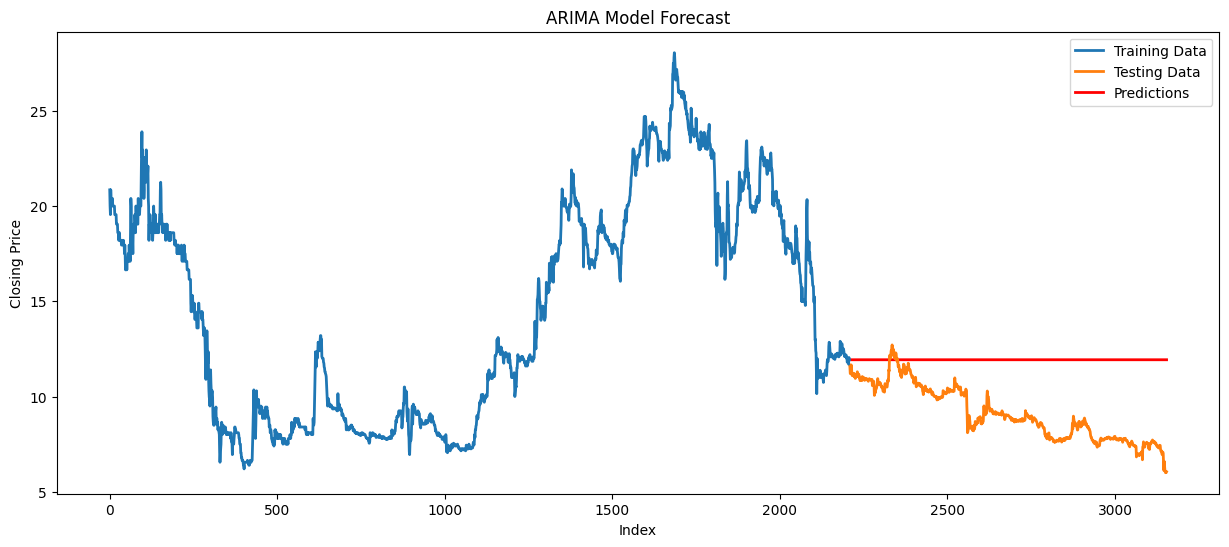

In [74]:
import numpy as np
import matplotlib.pyplot as plt

train_length = len(train)
test_length = len(test)

# Plot the data
plt.plot(np.arange(train_length), train, label='Training Data', linewidth=2, zorder=3)
plt.plot(np.arange(train_length, train_length + test_length), test, label='Testing Data', linewidth=2, zorder=2)
plt.plot(np.arange(train_length, train_length + test_length), forecast, color='red', label='Predictions', linewidth=2, zorder=1)

plt.title('ARIMA Model Forecast')
plt.xlabel('Index')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

#References


1. https://medium.com/@philippetousignant/understanding-time-series-stationarity-with-python-8c4e45f24d37#:~:text=Differencing%20is%20a%20simple%20and,the%20difference%20between%20consecutive%20values.

2. https://prof-frenzel.medium.com/kb-time-series-data-part-3-6e32032f7b49#:~:text=One%20prominent%20approach%20to%20achieving,the%20current%20and%20previous%20observations.&text=%E2%80%8BIn%20this%20method%2C%20each,subtracted%20from%20its%20immediate%20predecessor.

3. https://www.kaggle.com/datasets/aldukhi2/saudi-daily-stocks-history-test?select=KINGDOM_4280.csv
4. Introduction to Time Series Forecasting with Python by Jason Brownlee.
